# Buffett-Indicator -- a quantitative teardown
### 55 annual obs * ^GSPC price * predictive regression * HAC t * real-time expanding median * synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We regress next-year S&P return on the Buffett Indicator level with a Newey-West HAC t-stat, sort cheap vs expensive terciles, contrast the in-sample slope with a real-time (expanding-median) timing rule, and close with a synthetic positive control that proves the engine finds a valuation->return link when one exists.

> **Not investment advice.** Real data: Buffett Indicator (market cap / GDP) hardcoded in `data.py` (1971-2025); forward returns = ^GSPC **price** index, Dec/Dec (repo-level split-only cache). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffett_indicator import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=55, year_start=1971, year_end=2025, fp="479252b8a735",
    beta_per_100=-3.22, corr=-0.093, reg_r2=0.009, reg_t=-0.919,
    cheap_mean=10.0, mid_mean=9.9, exp_mean=8.2,
    cheap_up=78.9, mid_up=77.3, exp_up=64.3,
    strat_cagr=1.31, strat_cagr_net=1.30, bah_cagr=8.11,
    frac_invested=23.6, n_flips=4, excess_t=-3.764,
    ratio_2025=209.0, ratio_1974=42.0, ratio_1999=172.0, ratio_2021=207.0,
)


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Predictive-regression slope **-3.22pp / +100pp GDP**, right sign, but HAC t = **-0.92**, R^2 = **0.009**. |
| **Tradability** | `MIRAGE` | Real-time expanding-median timing earns **1.3%/yr** vs **8.1%/yr** buy-and-hold; excess HAC t = **-3.76**. |

> 💡 The slope points the way Buffett predicts (expensive -> lower return), but at a one-year horizon with n=55 it cannot be distinguished from zero, and acting on it is actively harmful.

## 1 - The claim, steelmanned

Let $V_Y$ be the Buffett Indicator at year-end $Y$ (market cap / GDP, in %) and $r_{Y+1}$ the S&P 500 price return in year $Y+1$. The hypotheses:

- **H1 (predictive slope).** In $r_{Y+1} = \alpha + \beta V_Y + \varepsilon$, the Buffett claim is $\beta < 0$ with $|t| \ge 2$ (HAC) -- high valuation forecasts low return.
- **H2 (monotonic terciles).** $E[r \mid \text{cheap}] > E[r \mid \text{mid}] > E[r \mid \text{expensive}]$.
- **H3 (tradable real-time rule).** An out-of-sample timing rule using only point-in-time information beats buy-and-hold net of costs.

We find H1 has the right sign but fails the t-bar; H2 holds weakly; H3 fails badly.

## 2 - So what? -- what rides on each answer

Valuation-ratio predictability is one of the most studied questions in asset pricing (Campbell-Shiller, Cochrane, Goyal-Welch). The theory is sound at long horizons: valuation ratios mean-revert and most of their variation is time-varying discount rates. The empirical knife-edge is **out-of-sample at short horizons**, where Goyal-Welch (2008) showed most predictors fail to beat the prevailing mean. The Buffett Indicator is exactly this case, dressed in folklore.

## 3 - How we'd know -- the protocol

- **Data.** Buffett Indicator year-end levels 1971-2025 (hardcoded); ^GSPC Dec/Dec **price** returns, indicator at $Y$ matched to return in $Y+1$ (one-year execution lag, no look-ahead).
- **Primary spec.** OLS $r_{Y+1} = \alpha + \beta V_Y$ with Newey-West HAC SE (automatic Bartlett lag).
- **Secondary.** Cheap/mid/expensive terciles (in-sample breakpoints -- a generous upper bound).
- **Honest spec.** Real-time timing: long iff $V_Y \le$ expanding median of prior readings; else cash (0%, price-only, conservative). Costs one-way x NAV per flip.
- **Positive control.** Synthetic AR(1) valuation with a planted slope $\beta$, to confirm the regression recovers a true effect.

> 💡 Price-only forward returns understate total returns by ~1.8pp/yr uniformly; this shifts every bar but not the *relative* cheap-vs-expensive comparison.

## 4 - The teardown

### 4a - The predictive regression with a HAC t-stat

Regress next-year return on the valuation level; report the Newey-West t.

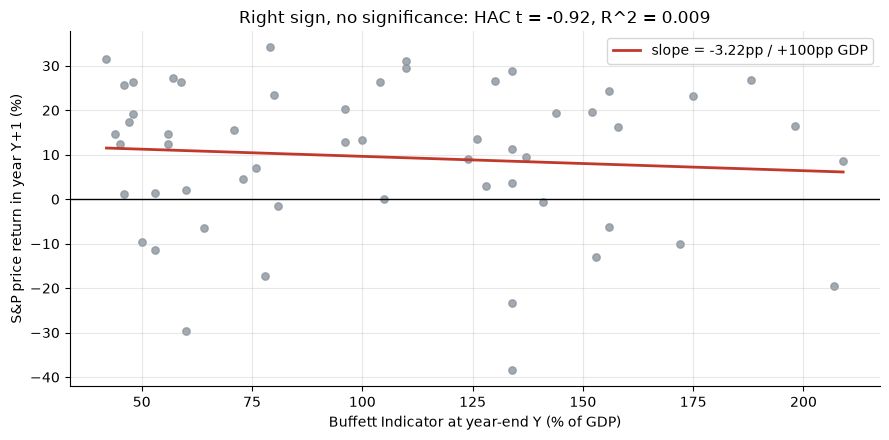

slope: -3.22pp return per +100pp of GDP  |  corr = -0.093
R^2 = 0.009  |  HAC t = -0.919  |  n = 55
|t| < 2 -> fails the REAL bar. The cloud is nearly flat.


In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    reg = st.predictive_regression(df)
    beta100 = reg['beta_per_100']*100  # pp return per +100pp GDP
    corr = reg['corr']; r2 = reg['r2']; tstat = reg['tstat']; n = reg['n']
    x = df['ratio'].to_numpy(); y = df['fwd_ret'].to_numpy()*100
else:
    beta100, corr, r2, tstat, n = (R['beta_per_100'], R['corr'], R['reg_r2'],
                                   R['reg_t'], R['n'])
    rng = np.random.default_rng(264)
    x = np.linspace(45, 205, R['n']) + rng.normal(0, 15, R['n'])
    y = 12.9 + (R['beta_per_100']/100)*x + rng.normal(0, 16, R['n'])

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.scatter(x, y, c=GREY, s=28, alpha=0.8)
xs = np.array([x.min(), x.max()])
slope = beta100/100; intercept = (y.mean() - slope*x.mean())
ax.plot(xs, intercept + slope*xs, c=RED, lw=2,
        label=f'slope = {beta100:+.2f}pp / +100pp GDP')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Buffett Indicator at year-end Y (% of GDP)')
ax.set_ylabel('S&P price return in year Y+1 (%)')
ax.set_title(f'Right sign, no significance: HAC t = {tstat:+.2f}, R^2 = {r2:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'slope: {beta100:+.2f}pp return per +100pp of GDP  |  corr = {corr:+.3f}')
print(f'R^2 = {r2:.3f}  |  HAC t = {tstat:+.3f}  |  n = {n}')
print('|t| < 2 -> fails the REAL bar. The cloud is nearly flat.')

> 💡 The slope is **negative** -- Buffett's direction -- but the scatter is a shapeless cloud. HAC t = **-0.92**, R^2 < **1%**. At one year out, valuation level is essentially uninformative about return *magnitude*.

### 4b - Cheap vs expensive terciles (in-sample, the generous version)

Even granting in-sample breakpoints, how big is the tilt?

In [3]:
if HAVE_REAL:
    terc = st.tercile_returns(df)
    print(terc.assign(mean_fwd_pct=(terc['mean_fwd']*100).round(1),
                      up_rate_pct=(terc['up_rate']*100).round(1))
          [['n','mean_fwd_pct','up_rate_pct']].to_string())
    cheap = float(terc.loc['cheap','mean_fwd'])*100
    exp = float(terc.loc['expensive','mean_fwd'])*100
else:
    cheap, exp = R['cheap_mean'], R['exp_mean']
    print(f"cheap: mean +{R['cheap_mean']}%  up {R['cheap_up']}%")
    print(f"mid:   mean +{R['mid_mean']}%  up {R['mid_up']}%")
    print(f"exp:   mean +{R['exp_mean']}%  up {R['exp_up']}%")
print()
print(f'Cheap-minus-expensive next-year return: {cheap-exp:+.1f}pp')
print('In the predicted direction, but small -- and in-sample breakpoints flatter it.')

            n  mean_fwd_pct  up_rate_pct
bucket                                  
cheap      19          10.0         78.9
mid        22           9.9         77.3
expensive  14           8.2         64.3

Cheap-minus-expensive next-year return: +1.8pp
In the predicted direction, but small -- and in-sample breakpoints flatter it.


> 💡 ~2pp/yr in the right direction. But these terciles use the **whole sample's** breakpoints -- you could not have known in 1995 that 96% would land in the 'mid' bucket. The honest, point-in-time version is next, and it is brutal.

### 4c - The real-time timing rule (expanding median) vs buy-and-hold

Long the S&P iff the indicator is at or below its expanding median; else cash.

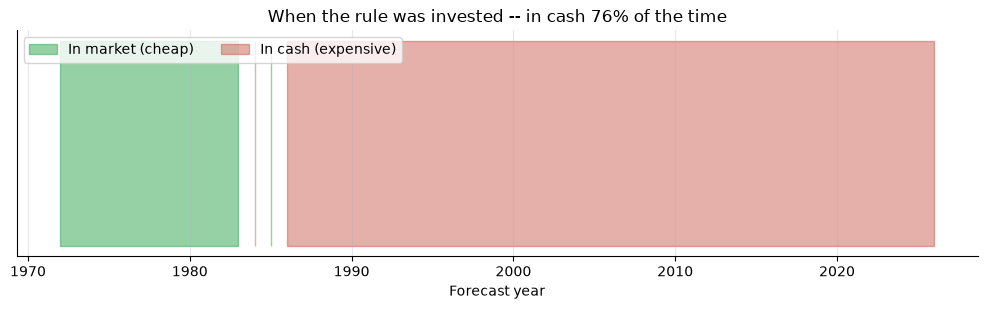

Buffett timing CAGR (gross): +1.31%/yr
Buffett timing CAGR (net 10bps/flip): +1.30%/yr  (4 flips)
Buy & hold CAGR (price): +8.11%/yr
Years invested: 23.6%  |  excess (strat-BAH) HAC t = -3.76


In [4]:
if HAVE_REAL:
    tim = st.timing_strategy(df)
    ss = st.strategy_stats(tim, one_way_bps=10.0)
    strat = ss['strat_cagr']*100; strat_net = ss['strat_cagr_net']*100
    bah = ss['bah_cagr']*100; frac = ss['frac_invested']*100
    flips = ss['n_flips']; ex_t = ss['excess_t']
    yrs = tim.index.values; in_mkt = tim['in_market'].values
else:
    strat, strat_net, bah = R['strat_cagr'], R['strat_cagr_net'], R['bah_cagr']
    frac, flips, ex_t = R['frac_invested'], R['n_flips'], R['excess_t']
    yrs = np.arange(R['year_start']+1, R['year_end']+2)
    in_mkt = (np.arange(R['n']) < 0.236*R['n'])

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.fill_between(yrs, 0, 1, where=in_mkt, color=GREEN, alpha=0.5, step='mid',
                label='In market (cheap)')
ax.fill_between(yrs, 0, 1, where=~np.asarray(in_mkt), color=RED, alpha=0.4, step='mid',
                label='In cash (expensive)')
ax.set_yticks([]); ax.set_xlabel('Forecast year')
ax.set_title(f'When the rule was invested -- in cash {100-frac:.0f}% of the time')
ax.legend(loc='upper left', ncol=2); plt.tight_layout(); plt.show()
print(f'Buffett timing CAGR (gross): {strat:+.2f}%/yr')
print(f'Buffett timing CAGR (net 10bps/flip): {strat_net:+.2f}%/yr  ({flips} flips)')
print(f'Buy & hold CAGR (price): {bah:+.2f}%/yr')
print(f'Years invested: {frac:.1f}%  |  excess (strat-BAH) HAC t = {ex_t:+.2f}')

> 💡 The rule sits in cash **76%** of the years. Its excess return over buy-and-hold has a HAC t of **-3.76** -- it *reliably underperforms*. Turnover is negligible (4 flips/55yr), so this is **not** a cost story: the indicator simply flagged the market 'expensive' for the entire modern bull run.

### 4d - Why it fails: the ratio's structural drift

The expanding median keeps rising, but the *contemporaneous* ratio rises faster -- so the rule is almost always 'expensive' after the mid-1990s.

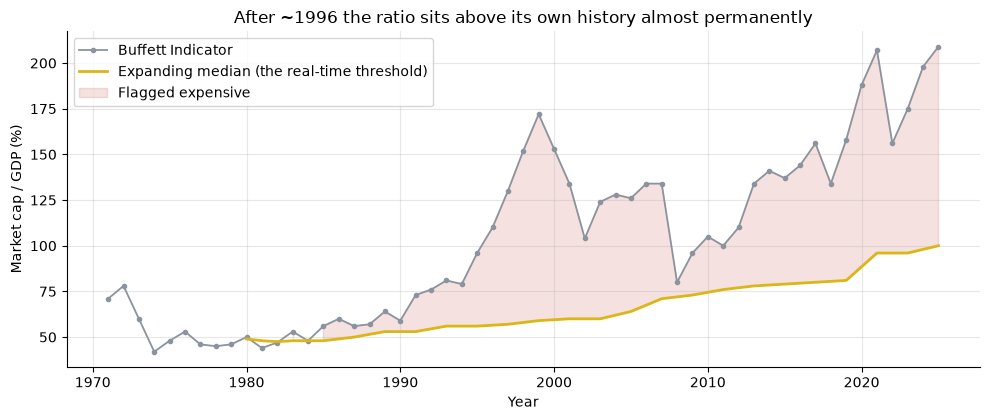

Years 1996-2025 flagged expensive by the real-time rule: 30/30


In [5]:
bi = data.buffett_table().sort_values('year').reset_index(drop=True)
exp_med = bi['ratio'].expanding(min_periods=10).median()
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(bi['year'], bi['ratio'], 'o-', c=GREY, lw=1.3, ms=3, label='Buffett Indicator')
ax.plot(bi['year'], exp_med, c=AMBER, lw=2, label='Expanding median (the real-time threshold)')
ax.fill_between(bi['year'], bi['ratio'], exp_med,
                where=(bi['ratio']>exp_med), color=RED, alpha=0.15, label='Flagged expensive')
ax.set_xlabel('Year'); ax.set_ylabel('Market cap / GDP (%)')
ax.set_title('After ~1996 the ratio sits above its own history almost permanently')
ax.legend(); plt.tight_layout(); plt.show()
above = int((bi['ratio'] > exp_med).loc[bi['year']>=1996].sum())
tot = int((bi['year']>=1996).sum())
print(f'Years 1996-2025 flagged expensive by the real-time rule: {above}/{tot}')

## 5 - The verdict

- **Signal `WEAK`** -- slope -3.22pp/+100pp GDP, right sign, but HAC t = -0.92, R^2 = 0.009 on n=55. The economics and the long-horizon literature are real (Campbell-Shiller, Cochrane), but the one-year signal cannot clear the |t| >= 2 bar -- literature support alone reads `WEAK`, not `REAL`.
- **Tradability `MIRAGE`** -- the honest real-time rule earns 1.3%/yr vs 8.1%/yr buy-and-hold (excess t = -3.76); it sat out the entire post-1996 bull market.

## 6 - Could you trade it? -- the excess-return reckoning

The buy-and-hold benchmark on the same price tape, with the strategy's shortfall.

In [6]:
if HAVE_REAL:
    shortfall = (ss['bah_cagr'] - ss['strat_cagr'])*100
    print(f"Buy & hold (price):      {ss['bah_cagr']*100:+.2f}%/yr")
    print(f"Buffett timing (gross):  {ss['strat_cagr']*100:+.2f}%/yr")
    print(f"Buffett timing (net):    {ss['strat_cagr_net']*100:+.2f}%/yr")
    print(f'Shortfall vs buy & hold: {shortfall:+.2f}pp/yr')
    print(f"Excess-return HAC t-stat: {ss['excess_t']:+.3f}  (negative = reliably worse)")
else:
    print(f"Buy & hold (price): {R['bah_cagr']:+.2f}%/yr")
    print(f"Buffett timing:     {R['strat_cagr']:+.2f}%/yr")
    print(f"Shortfall: {R['bah_cagr']-R['strat_cagr']:+.2f}pp/yr  |  excess t = {R['excess_t']:+.2f}")
print()
print('There is no version of the one-year timing trade that survives. The signal,')
print('such as it is, lives at horizons of 5-10 years -- not at the 1-year mark.')

Buy & hold (price):      +8.11%/yr
Buffett timing (gross):  +1.31%/yr
Buffett timing (net):    +1.30%/yr
Shortfall vs buy & hold: +6.80pp/yr
Excess-return HAC t-stat: -3.764  (negative = reliably worse)

There is no version of the one-year timing trade that survives. The signal,
such as it is, lives at horizons of 5-10 years -- not at the 1-year mark.


> 💡 The timing rule is dominated by passive exposure by ~7pp/yr. The opportunity cost of 'leaving the party' is the party.

## 7 - Going further -- the synthetic positive control

Does the regression detect a valuation->return link *when one exists*? We plant a mean-reversion slope in synthetic AR(1) valuation data and sweep its size.

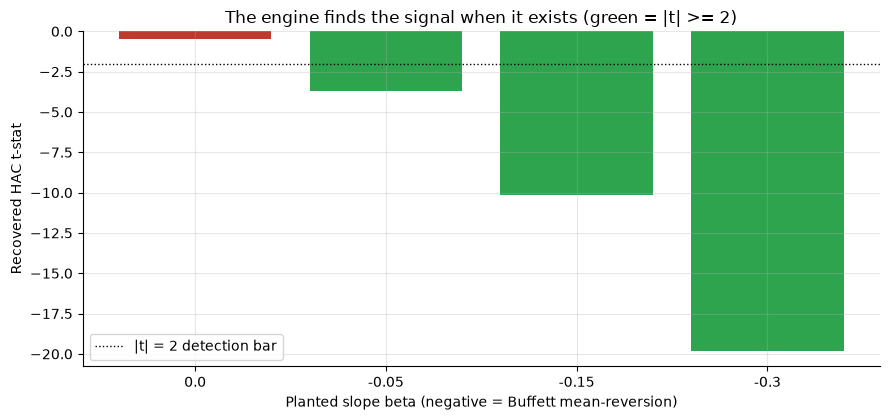

 beta   corr  hac_t  detected
 0.00 -0.023  -0.47     False
-0.05 -0.179  -3.69      True
-0.15 -0.447 -10.13      True
-0.30 -0.698 -19.79      True

Null (beta=0): |t| < 2. Even a small planted slope (beta=-0.05) is detected at n=400.
The real tape (n=55, one-year horizon) just does not carry that much signal.


In [7]:
planted = [0.0, -0.05, -0.15, -0.30]
rows = []
for b in planted:
    df_s, _ = data.synthetic_panel(n_years=400, beta=b, seed=264)
    r = st.predictive_regression(df_s)
    rows.append({'beta': b, 'corr': round(r['corr'],3),
                 'hac_t': round(r['tstat'],2),
                 'detected': abs(r['tstat'])>=2.0})
res = pd.DataFrame(rows)
colors = [GREEN if d else RED for d in res['detected']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(b) for b in planted], res['hac_t'], color=colors)
ax.axhline(-2, c='k', ls=':', lw=1, label='|t| = 2 detection bar')
ax.set_xlabel('Planted slope beta (negative = Buffett mean-reversion)')
ax.set_ylabel('Recovered HAC t-stat')
ax.set_title('The engine finds the signal when it exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Null (beta=0): |t| < 2. Even a small planted slope (beta=-0.05) is detected at n=400.')
print('The real tape (n=55, one-year horizon) just does not carry that much signal.')

The engine recovers a planted valuation->return relationship cleanly, and correctly returns a null when none is planted. The weak real result is therefore a statement about the **market and the one-year horizon**, not a failure of the method. At long horizons (5-10 years) valuation predictability re-emerges -- see [Study 120 -- Excess-CAPE-Yield](../../120-excess-cape-yield/).